In [129]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10,6)

df1 = pd.read_csv(
    "Tabela_5MB_Matheus_Mendes(Dados).csv",
    sep=";"
)

In [130]:
df1.columns = df1.columns.str.strip()
df1 = df1.rename(columns={"Parâmetros": "Parametro"})

In [131]:
df1_long = df1.melt(
    id_vars=["Parametro"],
    var_name="Data",
    value_name="Valor"
)

In [132]:
mapa = {
    "Temperatura do Ar (°C)": "Temp_Ar",
    "Temperatura da Água (°C)": "Temp_Agua",
    "pH": "pH",
    "Condutividade Elétrica (µS/cm)": "Condutividade",
    "Cloreto (mgCl/L)": "Cloreto",
    "OD (mg O2/L)": "OD",
    "DBO (mg O2/L)": "DBO",
    "Coliformes Termotolerantes (NMP/100mL)": "Coliformes",
    "Salinidade": "Salinidade",
    "Cor Verdadeira (uH)": "Cor",
    "Turbidez (uT)": "Turbidez",
    "Nitrato (mg/L)": "Nitrato",
    "Nitrito (mg/L)": "Nitrito",
    "Sólidos Totais (mg/L)": "Solidos_Total",
    "Clorofila (µg/L)": "Clorofila",
    "Alcalinidade (mg/L)": "Acalinidade",
    "Sólidos Suspensos (mg/L)": "Solidos_Susp",
    "Sólidos Dissolvidos (mg/L)": "Solidos_Disolv",
	"Fósforo Solúvel (mg/L)": "Fosforo_Soluv",
	"OD de Saturação (%)": "OD_Saturacao",
	"DQO": "DQO",
	"IET Valor": "IET_Valor",
	"Pluviometria (mm)": "Pluviometria"
}

df1_long["Parametro"] = df1_long["Parametro"].replace(mapa)

In [133]:
df1_long["Data"] = pd.to_datetime(df1_long["Data"], dayfirst=True)

In [134]:
df1_long = df1_long.dropna(subset=["Valor"])
df1_long = df1_long.reset_index(drop=True)

In [135]:
df1_long["Tabela"] = "Tabela_Mendes"

In [136]:
df1_long.head(20)

,Parametro,Data,Valor,Tabela
0,Temp_Ar,2021-04-20,26,Tabela_Mendes
1,Temp_Agua,2021-04-20,23,Tabela_Mendes
2,pH,2021-04-20,7,Tabela_Mendes
3,Condutividade,2021-04-20,62,Tabela_Mendes
4,Cloreto,2021-04-20,"8,8",Tabela_Mendes
5,OD,2021-04-20,7,Tabela_Mendes
6,DBO,2021-04-20,"0,8",Tabela_Mendes
7,Coliformes,2021-04-20,680,Tabela_Mendes
8,Salinidade,2021-04-20,0,Tabela_Mendes
9,Cor,2021-04-20,100,Tabela_Mendes


In [137]:
df2 = pd.read_excel("dados2.xlsx")



In [138]:
df2.columns = df2.columns.str.strip()
df2.rename(columns={df2.columns[0]: "Parametro"}, inplace=True)

In [139]:
df2_long = df2.melt(
    id_vars=["Parametro"],
    var_name="Data",
    value_name="Valor"
)

df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Parametro   22 non-null     object 
 1   16/02/2021  22 non-null     float64
 2   11/05/2021  22 non-null     float64
 3   10/08/2021  22 non-null     float64
 4   09/11/2021  22 non-null     float64
 5   08/02/2022  22 non-null     float64
 6   10/05/2022  22 non-null     float64
 7   09/08/2022  22 non-null     float64
 8   17/11/2022  22 non-null     float64
dtypes: float64(8), object(1)
memory usage: 1.7+ KB


In [140]:
df2_long["Valor"] = (
    df2_long["Valor"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .str.replace(">", "", regex=False)
    .str.strip()
)

df2_long["Valor"] = pd.to_numeric(df2_long["Valor"], errors="coerce")

In [141]:
mapa = {
    "Temperatura do Ar (°C)": "Temp_Ar",
    "Temperatura da Água (°C)": "Temp_Agua",
    "pH": "pH",
    "Condutividade Elétrica (µS/cm)": "Condutividade",
    "Cloreto (mgCl/L)": "Cloreto",
    "OD (mg O2/L)": "OD",
    "DBO (mg O2/L)": "DBO",
    "Coliformes Termotolerantes (NMP/100mL)": "Coliformes",
    "Salinidade": "Salinidade",
    "Cor Verdadeira (uH)": "Cor",
    "Turbidez (uT)": "Turbidez",
    "Nitrato (mg/L)": "Nitrato",
    "Nitrito (mg/L)": "Nitrito",
    "Sólidos Totais (mg/L)": "Solidos_Total",
    "Clorofila (µg/L)": "Clorofila",
    "Alcalinidade (mg/L)": "Acalinidade",
    "Sólidos Suspensos (mg/L)": "Solidos_Susp",
    "Sólidos Dissolvidos (mg/L)": "Solidos_Disolv",
	"Fósforo Solúvel (mg/L)": "Fosforo_Soluv",
	"OD de Saturação (%)": "OD_Saturacao",
	"DQO": "DQO",
	"IET Valor": "IET_Valor",
}

df2_long["Parametro"] = df2_long["Parametro"].replace(mapa)

In [142]:
df2_long["Data"] = pd.to_datetime(df2_long["Data"], dayfirst=True)

In [143]:
df2_long = df2_long.dropna(subset=["Valor"])
df2_long = df2_long.reset_index(drop=True)

In [144]:
df2_long["Tabela"] = "Tabela_thyago"

In [145]:
df2_long.head(30)

,Parametro,Data,Valor,Tabela
0,Temp_Ar,2021-02-16,29.00,Tabela_thyago
1,Temp_Agua,2021-02-16,26.00,Tabela_thyago
2,pH,2021-02-16,7.64,Tabela_thyago
3,Condutividade,2021-02-16,2544.00,Tabela_thyago
4,Cloreto,2021-02-16,552.80,Tabela_thyago
5,OD,2021-02-16,6.90,Tabela_thyago
6,DBO,2021-02-16,2.40,Tabela_thyago
7,Coliformes,2021-02-16,14000.00,Tabela_thyago
8,Salinidade,2021-02-16,1.30,Tabela_thyago
9,Cor,2021-02-16,100.00,Tabela_thyago


In [146]:
df3 = pd.read_excel("dados3.xlsx")

df3.info

<bound method DataFrame.info of                          Parâmetro  06/01/2021  07/04/2021  07/07/2021  \
0           Temperatura do Ar (°C)      30.000       26.00       25.00   
1         Temperatura da Água (°C)      30.000       23.00       21.00   
2                               pH       6.440        6.98        6.93   
3   Condutividade Elétrica (µS/cm)     168.000      214.00      150.00   
4                 Cloreto (mgCl/L)      28.210       31.10       17.60   
5                     OD (mg O2/L)       3.730        4.30        6.06   
6                    DBO (mg O2/L)       6.000        0.60        0.65   
7           Coliformes (NMP/100mL)   12000.000    22000.00     1700.00   
8                       Salinidade       0.100        0.10        0.10   
9                    Turbidez (uT)      60.000       15.00       15.00   
10                  Nitrato (mg/L)       0.137        0.08        0.08   
11                  Nitrito (mg/L)       0.050        0.05        0.05   
12    

In [147]:
df3.columns = df3.columns.str.strip()
df3.rename(columns={df3.columns[0]: "Parametro"}, inplace=True)

In [148]:
df3_long = df3.melt(
    id_vars=["Parametro"],
    var_name="Data",
    value_name="Valor"
)

df3.head()

,Parametro,06/01/2021,07/04/2021,07/07/2021,06/10/2021,04/01/2022,05/04/2022,05/07/2022,04/10/2022
0,Temperatura do Ar (°C),30.00,26.00,25.00,26.00,30.00,32.00,29.00,29.00
1,Temperatura da Água (°C),30.00,23.00,21.00,23.00,25.00,29.00,27.00,26.00
2,pH,6.44,6.98,6.93,6.97,7.02,6.92,6.98,6.96
3,Condutividade Elétrica (µS/cm),168.00,214.00,150.00,189.70,185.30,150.20,135.90,139.90
4,Cloreto (mgCl/L),28.21,31.10,17.60,27.23,36.15,30.12,18.30,22.40


In [149]:
df3_long["Valor"] = (
    df3_long["Valor"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .str.replace(">", "", regex=False)
    .str.strip()
)

df3_long["Valor"] = pd.to_numeric(df3_long["Valor"], errors="coerce")

In [150]:
mapa = {
    "Temperatura do Ar (°C)": "Temp_Ar",
    "Temperatura da Água (°C)": "Temp_Agua",
    "pH": "pH",
    "Condutividade Elétrica (µS/cm)": "Condutividade",
    "Cloreto (mgCl/L)": "Cloreto",
    "OD (mg O2/L)": "OD",
    "DBO (mg O2/L)": "DBO",
    "Coliformes Termotolerantes (NMP/100mL)": "Coliformes",
    "Salinidade": "Salinidade",
    "Cor Verdadeira (uH)": "Cor",
    "Turbidez (uT)": "Turbidez",
    "Nitrato (mg/L)": "Nitrato",
    "Nitrito (mg/L)": "Nitrito",
    "Sólidos Totais (mg/L)": "Solidos_Total",
    "Clorofila (µg/L)": "Clorofila",
    "Alcalinidade (mg/L)": "Acalinidade",
    "Sólidos Suspensos (mg/L)": "Solidos_Susp",
    "Sólidos Dissolvidos (mg/L)": "Solidos_Disolv",
	"Fósforo Solúvel (mg/L)": "Fosforo_Soluv",
	"OD de Saturação (%)": "OD_Saturacao",
	"DQO": "DQO",
	"IET Valor": "IET_Valor",
}

df3_long["Parametro"] = df3_long["Parametro"].replace(mapa)

In [151]:
df3_long["Data"] = pd.to_datetime(df3_long["Data"], dayfirst=True)

In [152]:
df3_long = df3_long.dropna(subset=["Valor"])
df3_long = df3_long.reset_index(drop=True)

In [153]:
df3_long["Tabela"] = "Tabela_Igarassu"

In [162]:
df3_long.head()

,Parametro,Data,Valor,Tabela
0,Temp_Ar,2021-01-06,30.00,Tabela_Igarassu
1,Temp_Agua,2021-01-06,30.00,Tabela_Igarassu
2,pH,2021-01-06,6.44,Tabela_Igarassu
3,Condutividade,2021-01-06,168.00,Tabela_Igarassu
4,Cloreto,2021-01-06,28.21,Tabela_Igarassu


In [155]:
df_final = pd.concat([df1_long, df2_long, df3_long], ignore_index=True)

In [156]:
df_final.head()

,Parametro,Data,Valor,Tabela
0,Temp_Ar,2021-04-20,26,Tabela_Mendes
1,Temp_Agua,2021-04-20,23,Tabela_Mendes
2,pH,2021-04-20,7,Tabela_Mendes
3,Condutividade,2021-04-20,62,Tabela_Mendes
4,Cloreto,2021-04-20,"8,8",Tabela_Mendes


In [157]:
df_final["Valor"] = (
    df_final["Valor"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .str.replace(">", "", regex=False)
    .str.strip()
)

df_final["Valor"] = pd.to_numeric(df_final["Valor"], errors="coerce")

In [158]:
comparativo_std = df_final.groupby(["Parametro", "Tabela"])["Valor"].std().unstack()

comparativo_std.round(2)

Tabela,Tabela_Igarassu,Tabela_Mendes,Tabela_thyago
Parametro,,,
Acalinidade,8.29,1.45,69.82
Cloreto,6.48,3.89,174.16
Clorofila,NaN,3.48,4.65
Coliformes,NaN,57945.91,11787.03
Coliformes (NMP/100mL),12503.49,NaN,NaN
Condutividade,27.60,9.62,766.99
Cor,NaN,32.83,60.67
DBO,1.80,0.32,4.95
DQO,NaN,NaN,NaN


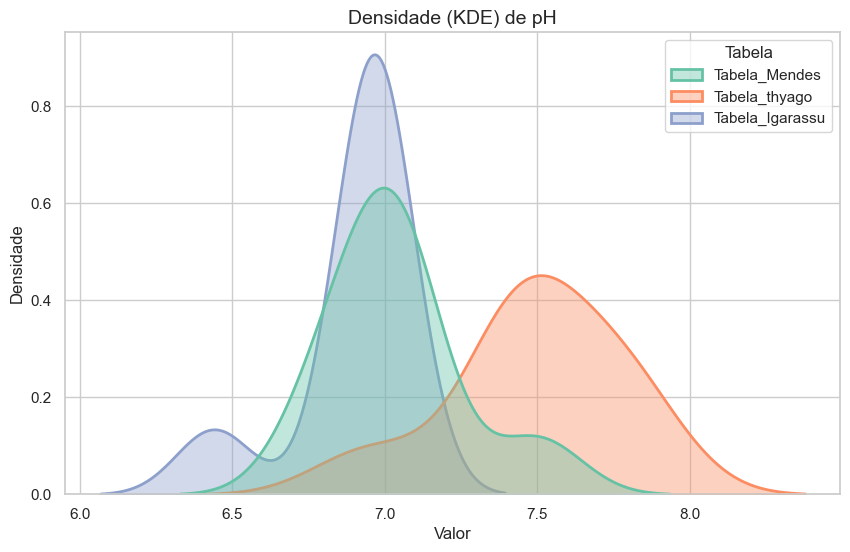

In [159]:
param = "pH"

plt.figure()

sns.kdeplot(
    data=df_final[df_final["Parametro"] == param],
    x="Valor",
    hue="Tabela",
    fill=True,
    alpha=0.4,
    linewidth=2
)

plt.title(f"Densidade (KDE) de {param}", fontsize=14)
plt.xlabel("Valor")
plt.ylabel("Densidade")
plt.show()

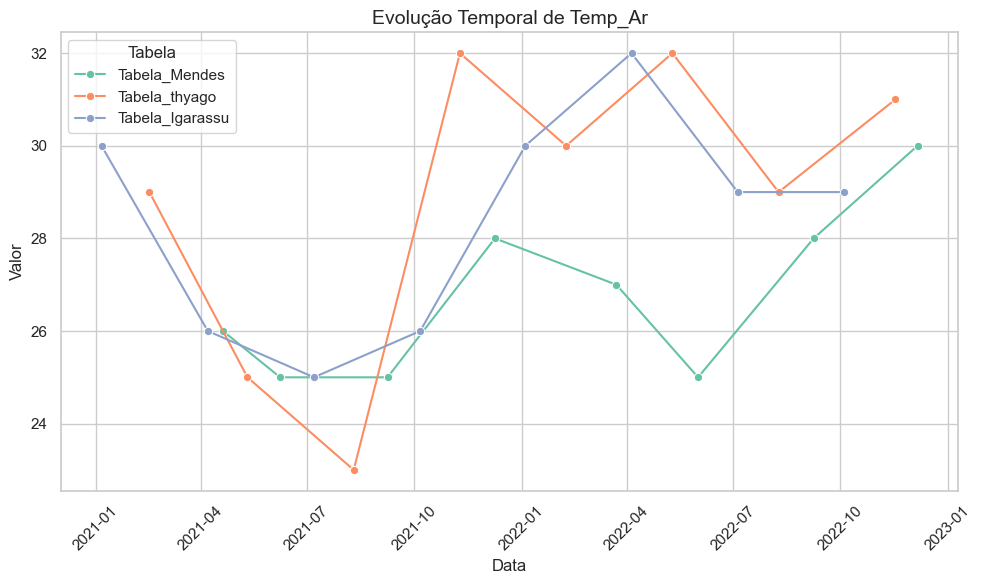

In [160]:
param = "Temp_Ar"

plt.figure()

sns.lineplot(
    data=df_final[df_final["Parametro"] == param],
    x="Data",
    y="Valor",
    hue="Tabela",
    marker="o"
)

plt.title(f"Evolução Temporal de {param}", fontsize=14)
plt.xticks(rotation=45)
plt.xlabel("Data")
plt.ylabel("Valor")
plt.legend(title="Tabela")
plt.tight_layout()
plt.show()

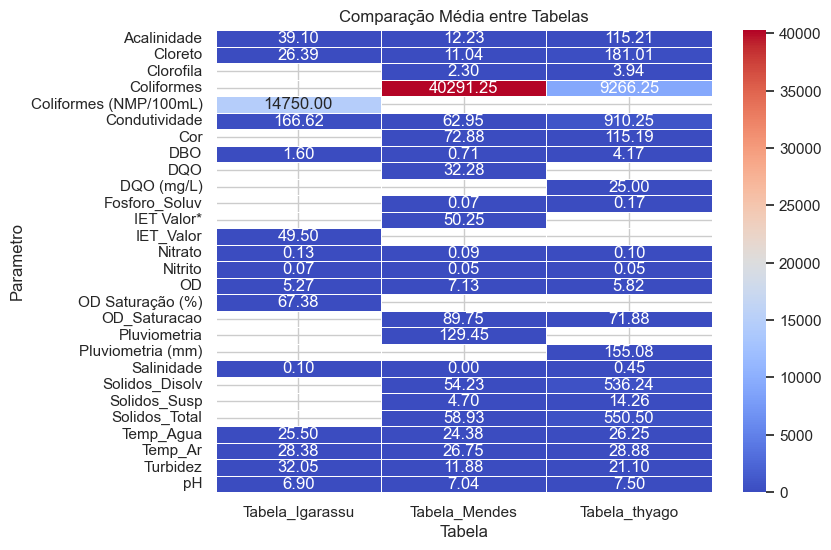

In [161]:
pivot = df_final.groupby(["Parametro", "Tabela"])["Valor"].mean().unstack()

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Comparação Média entre Tabelas")
plt.show()

In [163]:
df_final.to_excel("base_final.xlsx", index=False)